## Info
- Course Index :  6.2
- URL: https://www.coursera.org/learn/ai-deep-learning-capstone/home/module/2

## Objectives
- Load the data using Pytorch data loader
- Augment the image dataset using PyTorch
- Visualize the augmented data

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import skillsnetwork
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

## Download Data

In [2]:
extract_dir = "./data"
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4Z1fwRR295-1O3PMQBH6Dg/images-dataSAT.tar"

In [3]:
def check_skillnetwork_extraction(extract_dir):
    """ function to check whether data download and extraction method
    `skillsnetwork.prepare` would execute successfully, without downloading any data.
    This helps in early detection and fast fallback to explicit download and extraction
    using default libraries
    ###This is a hack for the code to run on non-cloud computing environment without errors
    """
    symlink_test = os.path.join(extract_dir, "symlink_test")
    if not os.path.exists(symlink_test):
        os.symlink(os.path.join(os.sep, "tmp"), symlink_test)
        print("Write permissions available for downloading and extracting the dataset tar file")
    os.unlink(symlink_test)
async def download_tar_dataset(url, tar_path, extract_dir):
    """function to explicitly download and extract the dataset tar file from cloud using native python libraries
    """
    if not os.path.exists(tar_path): # download only if file not downloaded already
        try:
            print(f"Downloading from {url}...")
            async with httpx.AsyncClient() as client:
                response = await client.get(url, follow_redirects=True)# Download the file asynchronously
                response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)

                with open(tar_path , "wb") as f:
                    f.write(response.content) # Save the downloaded file
                print(f"Successfully downloaded '{file_name}'.")
        except httpx.HTTPStatusError as http_err:
            print(f"HTTP error occurred during download: {http_err}")
        except Exception as download_err:
            print(f"An error occurred during the fallback process: {download_err}")
    else:
        print(f"dataset tar file already downloaded at: {tar_path}")
    with tarfile.open(tar_path, 'r:*') as tar_ref:
        tar_ref.extractall(path=extract_dir)
    print(f"✅ Successfully extracted to '{extract_dir}'.")

In [4]:
try:
    check_skillnetwork_extraction(extract_dir)
    await skillsnetwork.prepare(url = url, path = extract_dir, overwrite = True)
except Exception as e:
    print(e)
    # --- FALLBACK METHOD FOR DOWNLOADING THE DATA ---
    print("❌ Primary download/extration method failed.")
    print("Falling back to manual download and extraction...")

    # import libraries required for downloading and extraction
    import tarfile
    import httpx
    from pathlib import Path

    file_name = Path(url).name
    tar_path = os.path.join(extract_dir, file_name)
    print(f"tar_path: {os.path.exists(tar_path)} ___ {tar_path}")
    await download_tar_dataset(url, tar_path, extract_dir)

Write permissions available for downloading and extracting the dataset tar file


  0%|          | 0/6003 [00:00<?, ?it/s]

Saved to 'data'


In [5]:
base_dir = os.path.join(extract_dir, 'images_dataSAT')
dir_non_agri = os.path.join(base_dir, 'class_0_non_agri')
dir_agri = os.path.join(base_dir, 'class_1_agri')

## Dataset

In [6]:
class CustomBinaryClassDataset(Dataset):
    """A custom dataset for our agricultural land classification task."""
    def __init__(self, non_agri_dir, agri_dir, transform=None):
        """
        Args:
            non_agri_dir (string): Directory with all the non-agricultural images.
            agri_dir (string): Directory with all the agricultural images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.transform = transform
        self.image_paths = []
        self.labels = []

        # Load non-agri paths and assign label 0
        for fname in os.listdir(non_agri_dir):
            self.image_paths.append(os.path.join(non_agri_dir, fname))
            self.labels.append(0)

        # Load agri paths and assign label 1
        for fname in os.listdir(agri_dir):
            self.image_paths.append(os.path.join(agri_dir, fname))
            self.labels.append(1)

        temp = list(zip(self.image_paths, self.labels))
        np.random.shuffle(temp)
        self.image_paths, self.labels = zip(*temp)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB") # Ensure image is in RGB format

        label = self.labels[idx]

        # Apply transformations if they exist
        if self.transform:
            image = self.transform(image)

        return image, label

## Define transformations

In [7]:
test_transform = transforms.Compose([transforms.Resize((128, 128)),
                                     transforms.RandomHorizontalFlip(),
                                     transforms.RandomRotation(20),
                                     transforms.ToTensor(), # Converts PIL Image to a tensor and scales values to [0, 1]
                                     transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5]) # Normalize to [-1, 1]
])

### Task 1: Create a transformation pipeline custom_transform for:¶
1. image size = 64 x 64 pixels
2. RandomHorizontalFlip probability 0.5
3. RandomVerticalFlip probability 0.2
4. RandomRotation of 45 degrees

In [8]:
custom_transform = transforms.Compose([transforms.Resize((64, 64)),
                                     transforms.RandomHorizontalFlip(p=0.5),
                                       transforms.RandomVerticalFlip(p=0.2),
                                     transforms.RandomRotation(45),
                                     transforms.ToTensor(), # Converts PIL Image to a tensor and scales values to [0, 1]
                                     transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5]) # Normalize to [-1, 1]
])

### Dataloader

### Task 2: Get the dataset imagefolder_dataset using datasets.Imagefolder method and applying custom_transform

In [9]:
imagefolder_dataset = datasets.ImageFolder(
    root=base_dir,  # 这里需要替换为实验文档中指定的实际路径
    transform=custom_transform
)

### **Task 3**: Print the name and the class index from the **imagefolder_dataset**

In [10]:
print(f"Classes found by ImageFolder: {imagefolder_dataset.classes}")
print(f"Class to index mapping: {imagefolder_dataset.class_to_idx}")

Classes found by ImageFolder: ['class_0_non_agri', 'class_1_agri']
Class to index mapping: {'class_0_non_agri': 0, 'class_1_agri': 1}


In [11]:
BATCH_SIZE = 8 #  the number of images in a batch (batch size)

# --- Using your Custom Dataset ---
custom_dataset = CustomBinaryClassDataset(dir_non_agri, dir_agri, transform=custom_transform)
custom_loader = DataLoader(custom_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# --- Using the ImageFolder Dataset ---
imagefolder_loader = DataLoader(imagefolder_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [12]:
images_custom, labels_custom = next(iter(custom_loader))

print(f"Images batch shape (Custom loader): {images_custom.shape}")
print(f"Labels batch shape (Custom loader): {labels_custom.shape}")


Images batch shape (Custom loader): torch.Size([8, 3, 64, 64])
Labels batch shape (Custom loader): torch.Size([8])


### Task 4: Get a batch of images and labels from the imagefolder_loader and print their shape

In [13]:
images_inbuilt, labels_inbuilt = next(iter(custom_loader))
print(images_inbuilt.shape)
print(labels_inbuilt.shape)

torch.Size([8, 3, 64, 64])
torch.Size([8])


In [14]:
def imshow(img):
    """Helper function to un-normalize and display an image"""
    img = img / 2 + 0.5  # Un-normalize from [-1, 1] to [0, 1]
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # Convert from C,H,W to H,W,C

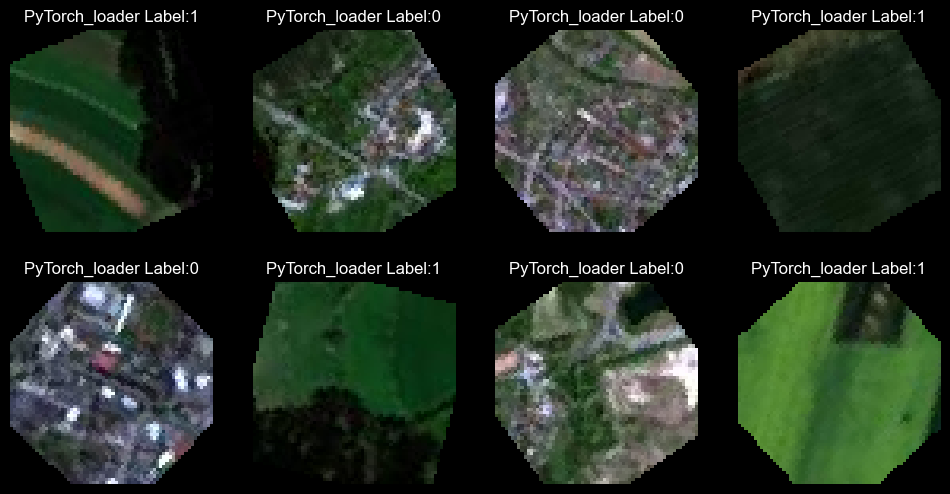

In [15]:
plt.figure(figsize = (12, 6))
for i in range(BATCH_SIZE):
    ax = plt.subplot(2, 4, i + 1)
    imshow(images_inbuilt[i])
    plt.title(f"PyTorch_loader Label:{labels_inbuilt[i].item()}")
    plt.axis("off")

### Task 5: Display the images in the Custom loader batch

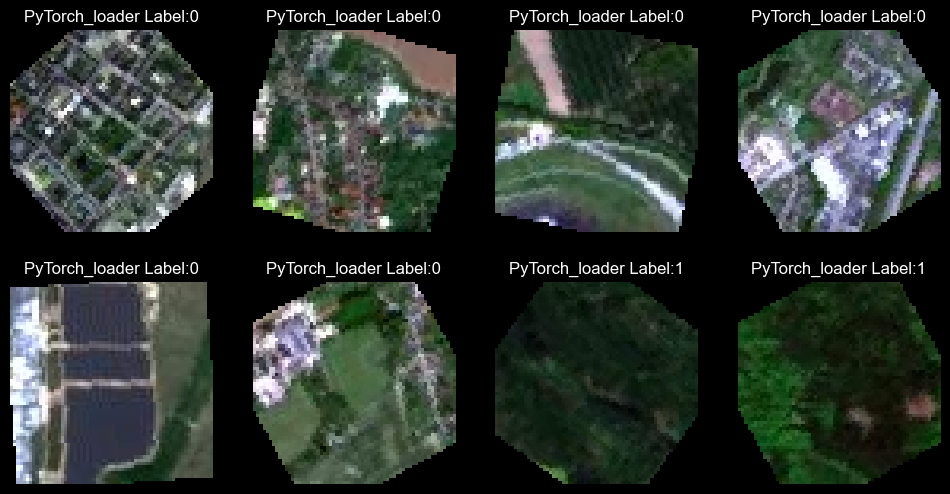

In [16]:
plt.figure(figsize = (12, 6))
for i in range(BATCH_SIZE):
    ax = plt.subplot(2, 4, i + 1)
    imshow(images_custom[i])
    plt.title(f"PyTorch_loader Label:{labels_custom[i].item()}")
    plt.axis("off")